# Deep Learning Classifiers in GeoWombat

This notebook demonstrates how to use GeoWombat's deep learning classifiers
for land cover classification using the same `fit()` / `predict()` / `fit_predict()`
API as the classical ML classifiers.

**Requirements:** `pip install geowombat[dl]`

This installs: `torch`, `pytorch-tabnet`, `torchgeo`, `segmentation-models-pytorch`

---
## Setup

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np

import geowombat as gw
from geowombat.data import (
    l8_224078_20200518,
    stac_training,
)
from geowombat.ml import fit, fit_predict, predict

### Prepare training labels

Load the training polygons bundled in `geowombat.data`. The `lc` column
contains integer land cover class labels (already encoded).

In [ ]:
# Load training polygons (integer 'lc' column, EPSG:4326)
labels = gpd.read_file(stac_training)
print(f"Labels shape: {labels.shape}")
print(f"CRS: {labels.crs}")
print(f"Classes: {sorted(labels['lc'].unique())}")
print(f"Number of classes: {labels['lc'].nunique()}")
labels.head()

### Preview the image and labels

In [ ]:
with gw.open(l8_224078_20200518, nodata=0) as src:
    print(f"Image shape: {src.shape}")
    print(f"Image dims:  {src.dims}")
    print(f"CRS:         {src.crs}")
    print(f"Resolution:  {src.res}")
    
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    src.sel(band=[3, 2, 1]).gw.imshow(mask=True, nodata=0, robust=True, ax=ax)
    labels.to_crs(src.crs).plot(
        ax=ax, column='lc', legend=True, 
        edgecolor='white', linewidth=1, alpha=0.5,
    )
    ax.set_title('Landsat 8 RGB with Training Polygons')
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

---
## 1. TabNet Classifier

TabNet is an attention-based tabular deep learning model. In GeoWombat, each pixel
is treated as a sample with spectral bands as features (pixel-wise classification).

Key parameters:
- `max_epochs`: Number of training epochs
- `batch_size`: Mini-batch size (default 1024)
- `patience`: Early stopping patience (default 10)
- `verbose`: 0=silent, 1=progress
- `device`: 'cpu', 'cuda', or 'auto'

### 1a. TabNet with `fit_predict()` (one-step)

In [4]:
from geowombat.ml.dl_classifiers import TabNetClassifier

with gw.config.update(ref_res=150):
    with gw.open(l8_224078_20200518, nodata=0) as src:
        # One-step: fit and predict in a single call
        y = fit_predict(
            src,
            TabNetClassifier(max_epochs=50, verbose=0),
            labels,
            col='lc',
        )

print(f"Prediction shape: {y.shape}")
print(f"Prediction dims:  {y.dims}")
print(f"Unique values:    {np.unique(y.values[np.isfinite(y.values)])}")

Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS



Early stopping occurred at epoch 26 with best_epoch = 16 and best_val_0_accuracy = 1.0


Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS


Prediction shape: (1, 372, 408)
Prediction dims:  ('band', 'y', 'x')
Unique values:    [1. 2. 3. 4.]


Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS


Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS


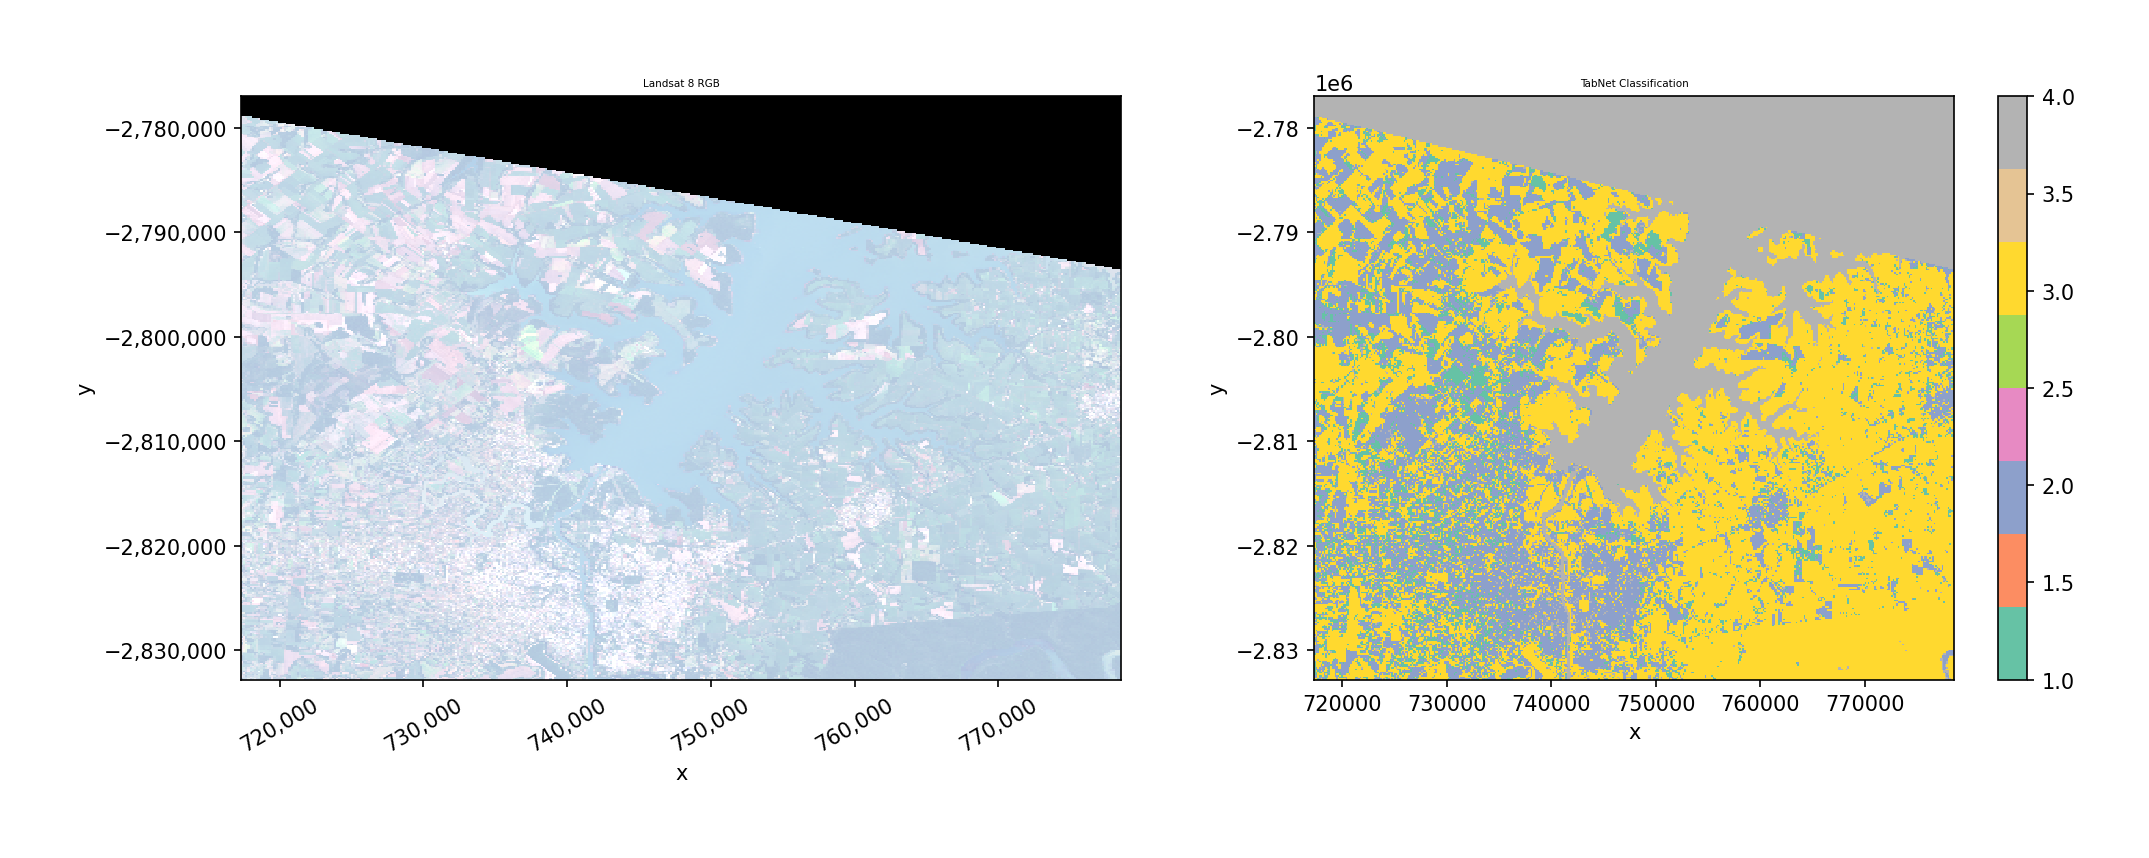

In [5]:
# Plot the TabNet classification result
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

with gw.config.update(ref_res=150):
    with gw.open(l8_224078_20200518, nodata=0) as src:
        src.sel(band=[3, 2, 1]).gw.imshow(mask=True, nodata=0, robust=True, ax=axes[0])
        axes[0].set_title('Landsat 8 RGB')

y.sel(band='targ').plot(ax=axes[1], cmap='Set2', add_colorbar=True)
axes[1].set_title('TabNet Classification')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

### 1b. TabNet with separate `fit()` then `predict()`

Use separate steps when you want to inspect the trained model,
save it, or predict on different data.

In [6]:
with gw.config.update(ref_res=150):
    with gw.open(l8_224078_20200518, nodata=0) as src:
        # Step 1: Fit the model
        clf = TabNetClassifier(max_epochs=50, verbose=0)
        X, Xy, clf = fit(src, clf, labels, col='lc')
        
        print(f"Model fitted: {clf.fitted_}")
        print(f"Number of classes: {clf._n_classes}")
        
        # Step 2: Predict (can use same or different data)
        y = predict(src, X, clf)

print(f"\nPrediction shape: {y.shape}")
vals = y.values[np.isfinite(y.values)]
print(f"Unique predictions: {np.unique(vals)}")

Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS



Early stopping occurred at epoch 26 with best_epoch = 16 and best_val_0_accuracy = 1.0
Model fitted: True
Number of classes: 4


Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS



Prediction shape: (1, 372, 408)
Unique predictions: [1. 2. 3. 4.]


Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS


---
## 2. L-TAE Classifier (Temporal Attention)

The Lightweight Temporal Attention Encoder (L-TAE) is designed for satellite
image time series. It uses multi-head temporal attention to classify each pixel
based on its spectral trajectory across multiple dates.

**Key requirement:** Data must have a `time` dimension (opened with `stack_dim='time'`).

Key parameters:
- `n_head`: Number of attention heads (default 4)
- `d_k`: Key dimension per head (default 32)
- `d_model`: Internal embedding dimension (default 128)
- `max_epochs`: Training epochs
- `lr`: Learning rate (default 1e-3)
- `device`: 'cpu', 'cuda', or 'auto'

### 2a. Open multi-temporal data

L-TAE requires time-stacked data. Here we stack the same image twice
to simulate a 2-date time series (in practice, use different acquisition dates).

In [7]:
from geowombat.ml.dl_classifiers import LTAEClassifier

with gw.config.update(ref_res=150):
    with gw.open(
        [l8_224078_20200518, l8_224078_20200518],
        stack_dim='time',
        nodata=0,
    ) as src:
        print(f"Multi-temporal shape: {src.shape}")
        print(f"Dims: {src.dims}")
        print(f"Time steps: {src.sizes['time']}")
        print(f"Bands: {src.sizes['band']}")

Multi-temporal shape: (2, 3, 372, 408)
Dims: ('time', 'band', 'y', 'x')
Time steps: 2
Bands: 3


### 2b. L-TAE with `fit_predict()`

In [8]:
with gw.config.update(ref_res=150):
    with gw.open(
        [l8_224078_20200518, l8_224078_20200518],
        stack_dim='time',
        nodata=0,
    ) as src:
        y = fit_predict(
            src,
            LTAEClassifier(
                max_epochs=50,
                verbose=0,
                d_model=32,   # smaller model for demo
                d_k=8,
                n_head=2,
            ),
            labels,
            col='lc',
        )

print(f"Prediction shape: {y.shape}")
print(f"Prediction dims:  {y.dims}")
print(f"Unique values:    {np.unique(y.values[np.isfinite(y.values)])}")

Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS


Prediction shape: (1, 372, 408)
Prediction dims:  ('band', 'y', 'x')
Unique values:    [1. 2. 3. 4.]


Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS


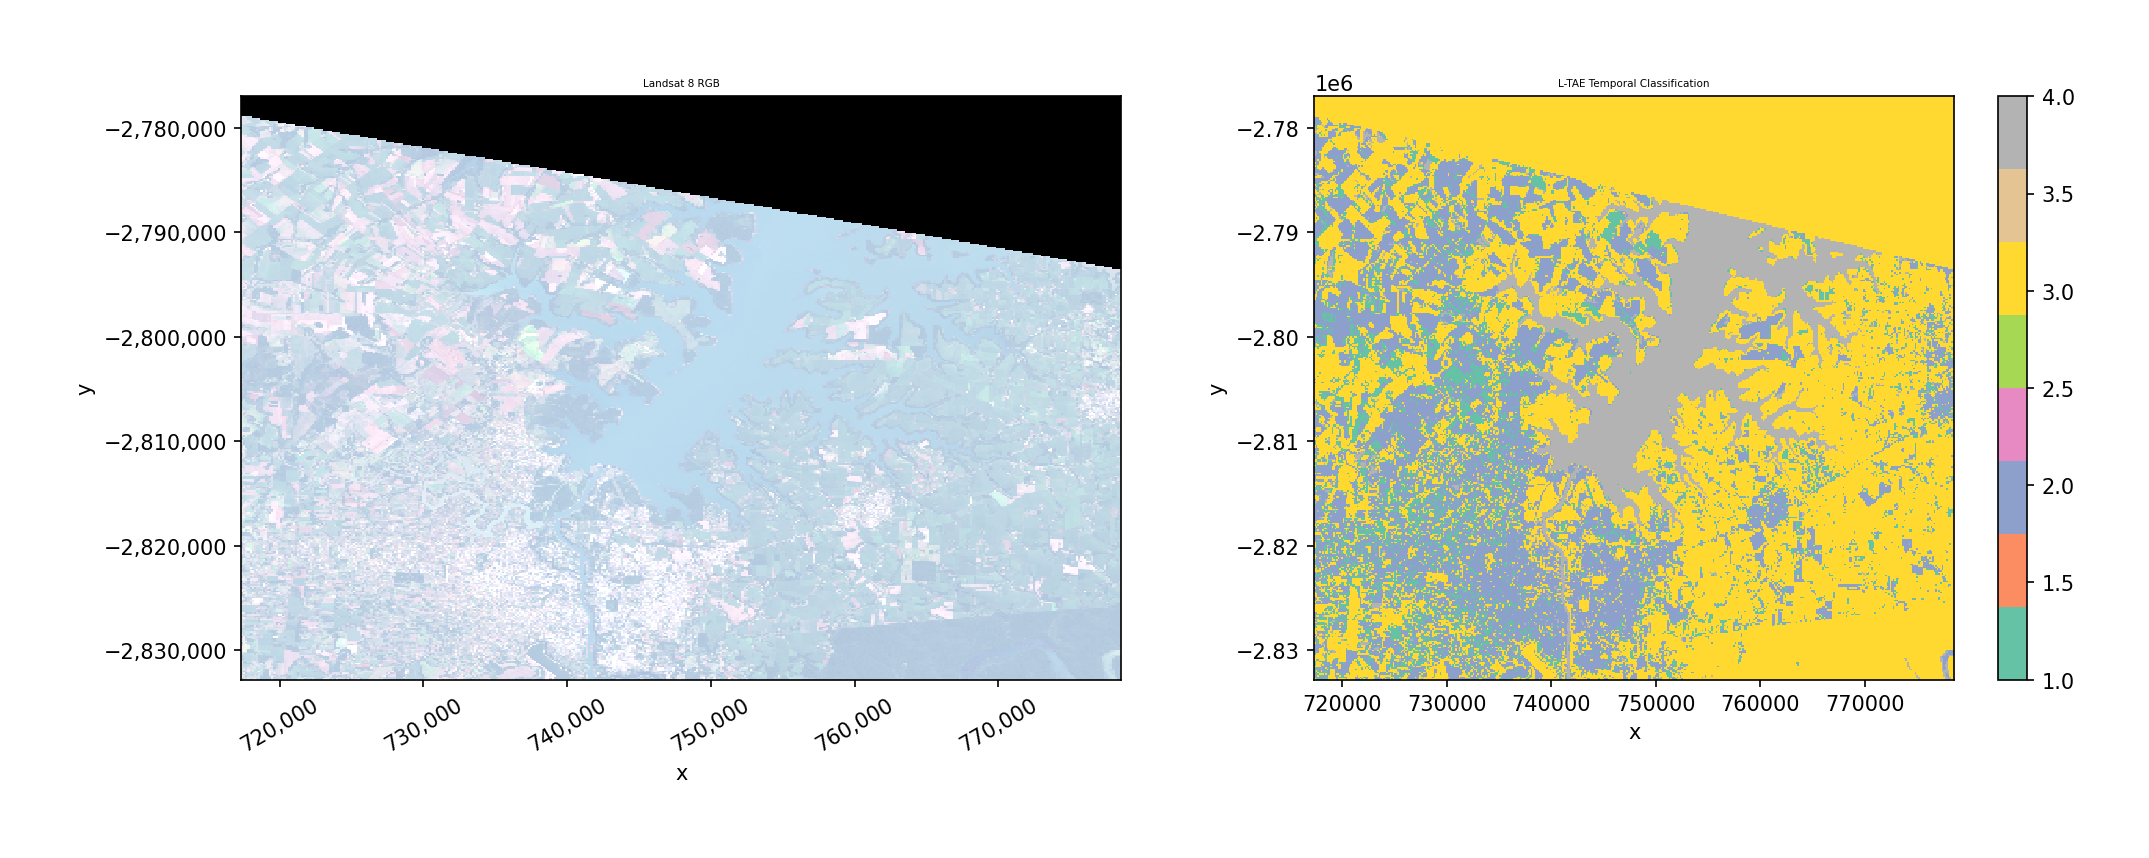

In [9]:
# Plot the L-TAE classification result
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

with gw.config.update(ref_res=150):
    with gw.open(l8_224078_20200518, nodata=0) as src:
        src.sel(band=[3, 2, 1]).gw.imshow(mask=True, nodata=0, robust=True, ax=axes[0])
        axes[0].set_title('Landsat 8 RGB')

y.sel(band='targ').plot(ax=axes[1], cmap='Set2', add_colorbar=True)
axes[1].set_title('L-TAE Temporal Classification')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

### 2c. L-TAE with separate `fit()` then `predict()`

In [10]:
with gw.config.update(ref_res=150):
    with gw.open(
        [l8_224078_20200518, l8_224078_20200518],
        stack_dim='time',
        nodata=0,
    ) as src:
        # Step 1: Fit
        clf = LTAEClassifier(
            max_epochs=50,
            verbose=0,
            d_model=32,
            d_k=8,
            n_head=2,
        )
        X, Xy, clf = fit(src, clf, labels, col='lc')
        
        print(f"Model fitted: {clf.fitted_}")
        print(f"Classes: {clf._n_classes}")
        print(f"Bands: {clf._n_bands}, Timesteps: {clf._n_timesteps}")
        
        # Step 2: Predict
        y = predict(src, X, clf)

print(f"\nPrediction shape: {y.shape}")
vals = y.values[np.isfinite(y.values)]
print(f"Unique predictions: {np.unique(vals)}")

Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS


Model fitted: True
Classes: 4
Bands: 3, Timesteps: 2

Prediction shape: (1, 372, 408)
Unique predictions: [1. 2. 3. 4.]


### 2d. L-TAE error handling: no time dimension

L-TAE raises a clear error if data doesn't have a `time` dimension.

In [11]:
# This will raise a ValueError
try:
    with gw.config.update(ref_res=150):
        with gw.open(l8_224078_20200518, nodata=0) as src:
            clf = LTAEClassifier()
            fit(src, clf, labels, col='lc')
except ValueError as e:
    print(f"Expected error: {e}")

Expected error: LTAEClassifier requires multi-temporal data with a 'time' dimension. Open data with stack_dim='time'.


---
## 3. Comparison with Classical ML

The DL classifiers use the exact same `fit()` / `predict()` / `fit_predict()` API
as sklearn-based classifiers. Here's a side-by-side comparison.

Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support


Early stopping occurred at epoch 26 with best_epoch = 16 and best_val_0_accuracy = 1.0


Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS
Warning 6: warp options does not support option WARP_EXTRAS


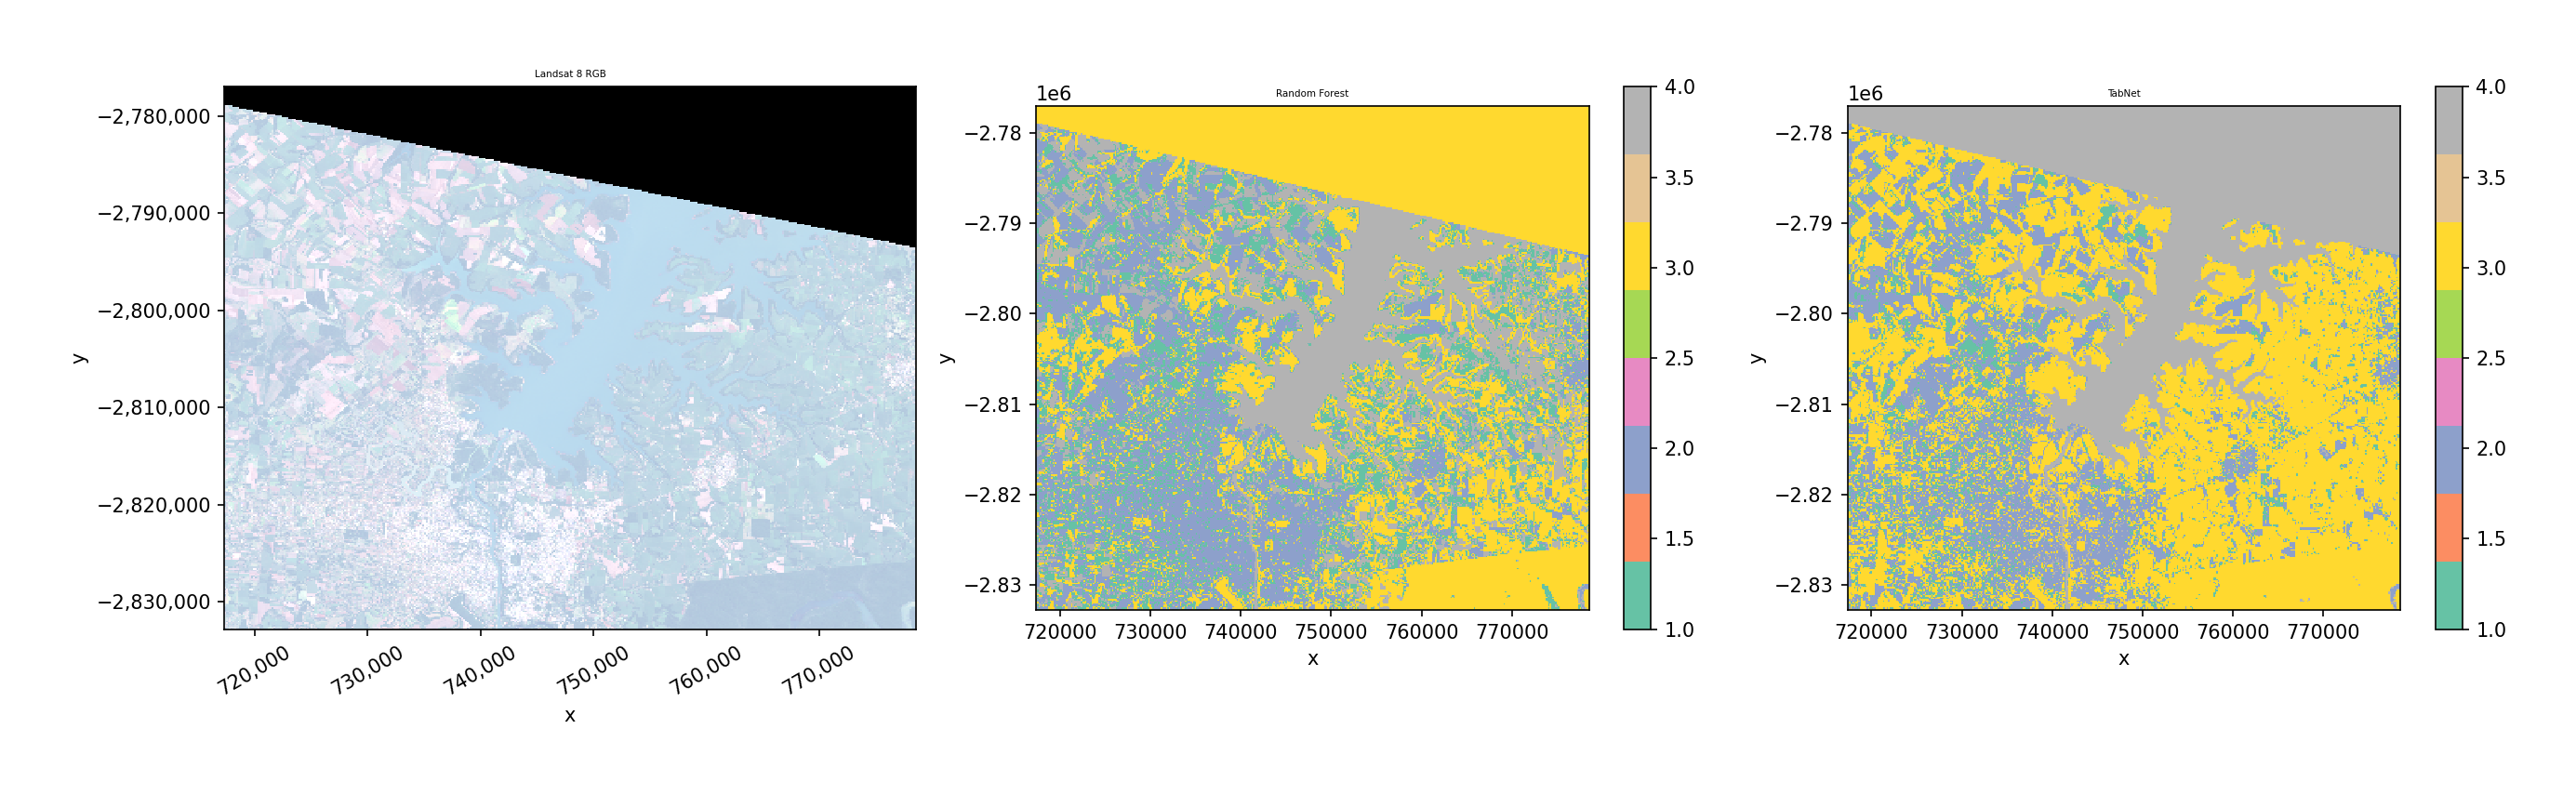

In [12]:
from sklearn.ensemble import RandomForestClassifier

with gw.config.update(ref_res=150):
    with gw.open(l8_224078_20200518, nodata=0) as src:
        # Classical ML: Random Forest
        y_rf = fit_predict(
            src,
            RandomForestClassifier(n_estimators=50, random_state=42),
            labels,
            col='lc',
        )
        
        # Deep Learning: TabNet
        y_tabnet = fit_predict(
            src,
            TabNetClassifier(max_epochs=50, verbose=0),
            labels,
            col='lc',
        )

# Plot side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

with gw.config.update(ref_res=150):
    with gw.open(l8_224078_20200518, nodata=0) as src:
        src.sel(band=[3, 2, 1]).gw.imshow(mask=True, nodata=0, robust=True, ax=axes[0])
        axes[0].set_title('Landsat 8 RGB')

y_rf.sel(band='targ').plot(ax=axes[1], cmap='Set2', add_colorbar=True)
axes[1].set_title('Random Forest')
axes[1].set_aspect('equal')

y_tabnet.sel(band='targ').plot(ax=axes[2], cmap='Set2', add_colorbar=True)
axes[2].set_title('TabNet')
axes[2].set_aspect('equal')

plt.tight_layout()
plt.show()

---
## 4. TorchGeo Pretrained Model Reference

TorchGeo provides 60+ pretrained encoder weights for satellite-specific feature extraction.
These can be used with `TorchGeoClassifier(backbone=..., weights='...')` to leverage
encoders pre-trained on satellite imagery (Sentinel-2, Landsat, NAIP, etc.).

The table below is generated programmatically — it auto-updates as TorchGeo adds new weights.

In [13]:
import torchgeo.models
import enum
import pandas as pd

rows = []
for attr_name in sorted(dir(torchgeo.models)):
    obj = getattr(torchgeo.models, attr_name)
    if not attr_name.endswith('_Weights'):
        continue
    if not (isinstance(obj, type) and issubclass(obj, enum.Enum)):
        continue
    backbone = attr_name.replace('_Weights', '')
    for member in obj:
        meta = member.meta if hasattr(member, 'meta') else {}
        rows.append({
            'Backbone': backbone,
            'Weight': f'{attr_name}.{member.name}',
            'Sensor': meta.get('dataset', ''),
            'In Channels': meta.get('in_chans', ''),
            'Bands': ', '.join(meta.get('bands', [])),
        })

df = pd.DataFrame(rows)
print(f"Total pretrained weights available: {len(df)}")
df.sort_values(['In Channels', 'Backbone']).reset_index(drop=True)

Total pretrained weights available: 124


,Backbone,Weight,Sensor,In Channels,Bands
0,ResNet50,ResNet50_Weights.SENTINEL1_ALL_DECUR,SSL4EO-S12,2,"VV, VH"
1,ResNet50,ResNet50_Weights.SENTINEL1_ALL_MOCO,SSL4EO-S12,2,"VV, VH"
2,ResNet50,ResNet50_Weights.SENTINEL1_GRD_CLOSP,CrisisLandMark,2,"VV, VH"
3,ResNet50,ResNet50_Weights.SENTINEL1_GRD_GEOCLOSP,CrisisLandMark,2,"VV, VH"
4,ResNet50,ResNet50_Weights.SENTINEL1_GRD_SOFTCON,SSL4EO-S12,2,"VV, VH"
...,...,...,...,...,...
119,CROMALarge,CROMALarge_Weights.CROMA_VIT,SSL4EO,,
120,CopernicusFM_Base,CopernicusFM_Base_Weights.CopernicusFM_ViT,Copernicus-Pretrain,,
121,DOFABase16,DOFABase16_Weights.DOFA_MAE,"SatlasPretrain, Five-Billion-Pixels, HySpecNet...",,
122,DOFALarge16,DOFALarge16_Weights.DOFA_MAE,"SatlasPretrain, Five-Billion-Pixels, HySpecNet...",,


---
## 5. STAC + TorchGeo Pretrained Model Example

Download Sentinel-2 imagery from a STAC catalog over the same area as our bundled
Landsat data, then classify it using a TorchGeo U-Net with a pretrained encoder.

**Requirements:** `pip install geowombat[stac]` and network access.

We use `composite_stac()` to create a cloud-free median composite, which
automatically handles cloud masking using the Sentinel-2 SCL band. Training
labels are loaded from `stac_training.geojson` (bundled in `geowombat.data`),
which has a `lc` column with integer class labels in EPSG:4326.

In [ ]:
from geowombat.core.stac import composite_stac
from geowombat.ml.dl_classifiers import TorchGeoClassifier

# Create a cloud-free Sentinel-2 RGB composite over the Landsat test area
# composite_stac() auto-masks clouds using the SCL band and takes the median
try:
    data, metadata = composite_stac(
        stac_catalog="element84_v1",
        collection="sentinel_s2_l2a",
        bounds=(-54.65, -25.41, -54.58, -25.25),
        epsg=32621,
        bands=["red", "green", "blue"],
        start_date="2023-06-01",
        end_date="2023-12-31",
        cloud_cover_perc=30,
        resolution=100.0,
        frequency="YS",       # yearly composite
        agg="median",          # median pixel value
        max_items=10,
        compute=True,
    )
    # composite_stac returns (time, band, y, x); take the single composite
    img = data.isel(time=0) if 'time' in data.dims else data
    print(f"Composite shape: {img.shape}")
    print(f"Dims: {img.dims}")
    STAC_OK = True
except Exception as e:
    print(f"STAC download failed (need network): {e}")
    print("Skipping STAC examples.")
    STAC_OK = False

In [ ]:
# Plot the downloaded Sentinel-2 image with training polygons
if STAC_OK:
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    img.plot.imshow(robust=True, ax=ax)
    labels.to_crs(img.attrs.get('crs', labels.crs)).plot(
        ax=ax, column='lc', legend=True,
        edgecolor='white', linewidth=1, alpha=0.5,
    )
    ax.set_title('Sentinel-2 RGB with Training Polygons')
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()
else:
    print("Skipped — no STAC data available.")

In [ ]:
# Classify the Sentinel-2 image using a pretrained TorchGeo U-Net
if STAC_OK:
    clf = TorchGeoClassifier(
        model='unet',
        backbone='resnet18',
        weights='ResNet18_Weights.SENTINEL2_RGB_MOCO',
        patch_size=32,
        max_epochs=5,
        batch_size=4,
        verbose=0,
    )
    y_stac = fit_predict(img, clf, labels, col='lc')

    print(f"Prediction shape: {y_stac.shape}")
    print(f"Unique values: {np.unique(y_stac.values[np.isfinite(y_stac.values)])}")
else:
    print("Skipped — no STAC data available.")

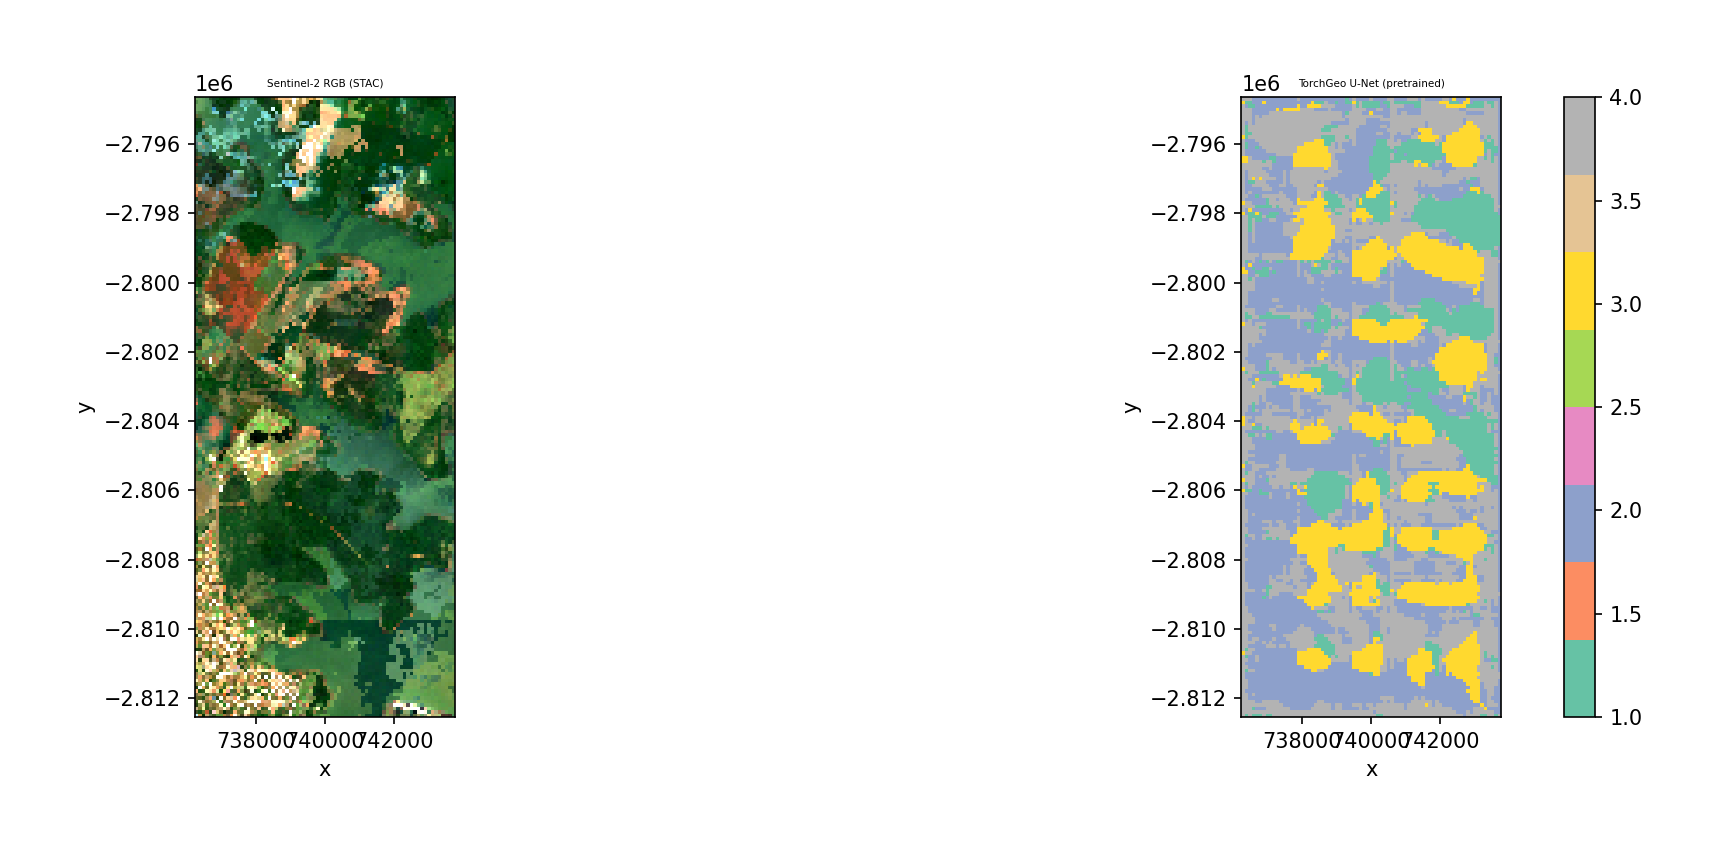

In [24]:
# Plot STAC classification result
if STAC_OK:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    img.plot.imshow(robust=True, ax=axes[0])
    axes[0].set_title('Sentinel-2 RGB (STAC)')
    axes[0].set_aspect("equal")

    y_stac.sel(band='targ').plot(ax=axes[1], cmap='Set2', add_colorbar=True)
    axes[1].set_title('TorchGeo U-Net (pretrained)')
    axes[1].set_aspect('equal')

    plt.tight_layout()
    plt.show()
else:
    print("Skipped — no STAC data available.")

---
## Notes

- **`n_classes` is auto-inferred** from the label column during `fit()`. You never need to specify it.
- **Feature normalization** is handled internally — raw DN values are standardized before training/prediction.
- **Labels use 1-based encoding** internally (0 = nodata). The classifiers handle the conversion to 0-based for PyTorch and back.
- **`ref_res`** controls the output resolution. Use a coarser resolution (e.g., 150-300m) for faster demos.
- **Device**: Pass `device='cuda'` or `device='auto'` to use GPU acceleration.
- For real workflows, increase `max_epochs` (e.g., 50-200) and use full resolution data.
- L-TAE is most useful with real multi-date imagery where temporal patterns differ between classes.
- This demo uses the same image stacked twice for L-TAE — in practice, use imagery from different dates.
- The pretrained weights table (Section 4) auto-updates when TorchGeo adds new models.
- STAC examples (Section 5) require network access; they are skipped gracefully if offline.